# Dataset: FICO

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:
df = pd.read_csv("data/FICO/FICO_uncleaned.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10459 entries, 0 to 10458
Data columns (total 24 columns):
 #   Column                              Non-Null Count  Dtype 
---  ------                              --------------  ----- 
 0   RiskPerformance                     10459 non-null  object
 1   ExternalRiskEstimate                10459 non-null  int64 
 2   MSinceOldestTradeOpen               10459 non-null  int64 
 3   MSinceMostRecentTradeOpen           10459 non-null  int64 
 4   AverageMInFile                      10459 non-null  int64 
 5   NumSatisfactoryTrades               10459 non-null  int64 
 6   NumTrades60Ever2DerogPubRec         10459 non-null  int64 
 7   NumTrades90Ever2DerogPubRec         10459 non-null  int64 
 8   PercentTradesNeverDelq              10459 non-null  int64 
 9   MSinceMostRecentDelq                10459 non-null  int64 
 10  MaxDelq2PublicRecLast12M            10459 non-null  int64 
 11  MaxDelqEver                         10459 non-null  in

In [4]:
df.shape

(9871, 24)

In [44]:
df.head()

,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [14]:
df.describe()

,ExternalRiskEstimate,MSinceOldestTradeOpen,MSinceMostRecentTradeOpen,AverageMInFile,NumSatisfactoryTrades,NumTrades60Ever2DerogPubRec,NumTrades90Ever2DerogPubRec,PercentTradesNeverDelq,MSinceMostRecentDelq,MaxDelq2PublicRecLast12M,...,PercentInstallTrades,MSinceMostRecentInqexcl7days,NumInqLast6M,NumInqLast6Mexcl7days,NetFractionRevolvingBurden,NetFractionInstallBurden,NumRevolvingTradesWBalance,NumInstallTradesWBalance,NumBank2NatlTradesWHighUtilization,PercentTradesWBalance
count,9861.000000,9871.000000,9871.000000,9871.000000,9871.000000,9871.000000,9871.000000,9871.000000,9871.000000,9871.000000,...,9871.000000,9871.000000,9871.000000,9871.000000,9871.000000,9871.000000,9871.000000,9871.000000,9871.000000,9871.000000
mean,72.060440,195.714315,9.588492,78.778138,21.121467,0.581400,0.384763,92.359943,7.701347,5.757978,...,34.618681,0.191369,1.455982,1.397123,34.050147,42.027657,3.910850,1.570358,0.555263,66.313241
std,9.871795,101.936102,12.963398,34.066063,11.321396,1.238783,0.993223,11.772876,20.728177,1.644518,...,17.953432,5.853077,2.136161,2.096102,29.210292,41.614214,3.356217,3.345442,2.610624,22.243329
min,33.000000,-8.000000,0.000000,4.000000,0.000000,0.000000,0.000000,0.000000,-8.000000,0.000000,...,0.000000,-8.000000,0.000000,0.000000,-8.000000,-8.000000,-8.000000,-8.000000,-8.000000,-8.000000
25%,64.000000,131.000000,3.000000,57.000000,13.000000,0.000000,0.000000,89.000000,-7.000000,5.000000,...,21.000000,0.000000,0.000000,0.000000,8.000000,-8.000000,2.000000,1.000000,0.000000,50.000000
50%,72.000000,183.000000,6.000000,76.000000,20.000000,0.000000,0.000000,97.000000,0.000000,6.000000,...,33.000000,0.000000,1.000000,1.000000,28.000000,52.000000,3.000000,2.000000,1.000000,67.000000
75%,80.000000,255.000000,12.000000,97.000000,28.000000,1.000000,0.000000,100.000000,15.000000,7.000000,...,45.000000,1.000000,2.000000,2.000000,56.000000,80.000000,5.000000,3.000000,1.000000,83.000000
max,94.000000,803.000000,383.000000,383.000000,79.000000,19.000000,19.000000,100.000000,83.000000,9.000000,...,100.000000,24.000000,66.000000,66.000000,232.000000,471.000000,32.000000,23.000000,18.000000,100.000000


In [6]:
# Replace all "-9", "-8", "-7" values with NaN
removal_code = [-9]
df = df.replace(removal_code, np.nan)

In [10]:
y = df['RiskPerformance']
X = df.drop(columns=['RiskPerformance'])

In [15]:
# Check for number of [-8, -7] values per column
removal_code = [-8, -7]

# Replace all "-8", "-7" values with 0
X = X.replace(removal_code, 0)

X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10459 entries, 0 to 10458
Data columns (total 23 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   ExternalRiskEstimate                9861 non-null   float64
 1   MSinceOldestTradeOpen               9871 non-null   float64
 2   MSinceMostRecentTradeOpen           9871 non-null   float64
 3   AverageMInFile                      9871 non-null   float64
 4   NumSatisfactoryTrades               9871 non-null   float64
 5   NumTrades60Ever2DerogPubRec         9871 non-null   float64
 6   NumTrades90Ever2DerogPubRec         9871 non-null   float64
 7   PercentTradesNeverDelq              9871 non-null   float64
 8   MSinceMostRecentDelq                9871 non-null   float64
 9   MaxDelq2PublicRecLast12M            9871 non-null   float64
 10  MaxDelqEver                         9871 non-null   float64
 11  NumTotalTrades                      9871 

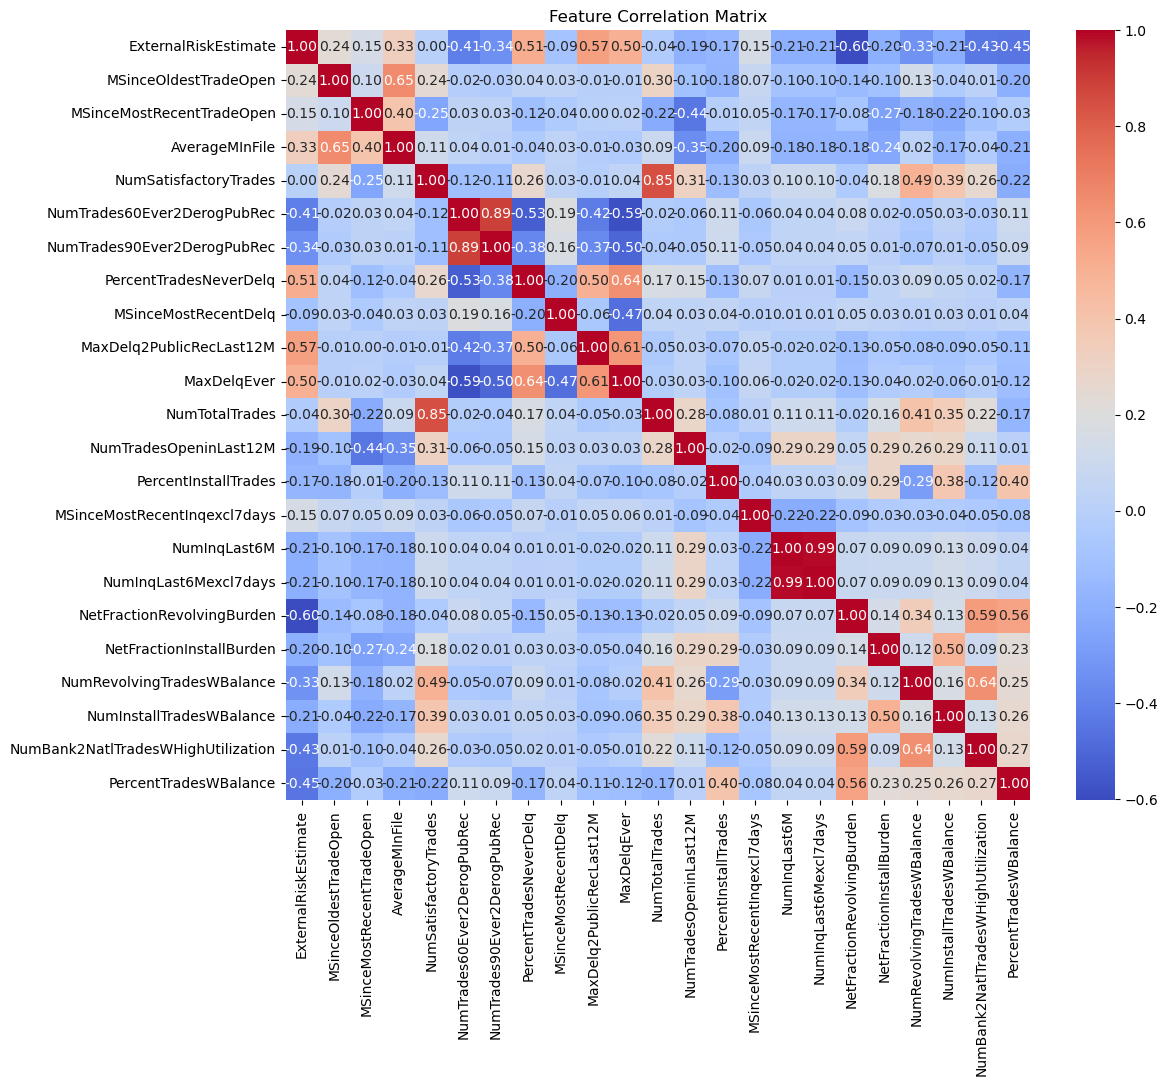

In [16]:
# Seaborne for a nice annotated correlation heatmap
import seaborn as sns
plt.figure(figsize=(12,10))
correlation_matrix = X.corr()
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Feature Correlation Matrix")
plt.show()